# Intro

This notebook provides minimal functionality for applying DMD to noisy climate data. 

Fit DMD to SVD modes of ERA5. 

1.  Pick mode
2. Pick its tail
3. Detrend by subtracting polyfit 
4. Fit DMD to detrended data
5. Reconstruct data

In [246]:
%load_ext autoreload
%autoreload 2
import dill

import numpy as np
import matplotlib.pyplot as plt

from pydmd import DMD, BOPDMD, FbDMD, MrDMD
from pydmd.plotter import plot_eigs, plot_summary, plot_modes_2D
from pydmd.preprocessing import hankel_preprocessing

from IPython.display import display
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from scipy.ndimage import gaussian_filter

from tqdm.autonotebook import tqdm, trange

from scipy.signal import fftconvolve

import sys

sys.path.insert(0, '../src/WeatherDMD/')

from WeatherDMD.plot_jupyter import contour_compare, contour_data, plot_data1
from WeatherDMD.data_wrangle import get_days_before, get_test_set, window_mean
from WeatherDMD.dmd_routines import reshape_data2dmd, train_dmd, reshape_Psi2data, eval_dmd

import xarray
import netCDF4 as nc
from netCDF4 import Dataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data


In [14]:
with open('../temp_data/V_2m_temperature.npy', 'rb') as f:
   U = np.load(f)

U.shape


(744, 744)

## Visualise data

In [247]:
plot_data1(U)

interactive(children=(IntSlider(value=0, description='f(i, x)', max=743), Output()), _dom_classes=('widget-int…

## Subset data

In [267]:
input = U[0]
t_train = np.arange(-input.shape[0], 0)

### thin

In [268]:
input_thin  = input[::24]
t_train_thin = t_train[::24]

### tail

In [285]:
input_tail_train = input[-240:-120]
t_train_tail_train = t_train[-240:-120]

input_tail_test = input[-120:]
t_train_tail_test = t_train[-120:]


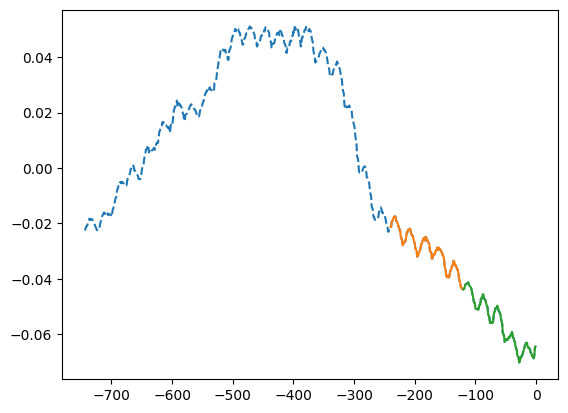

In [286]:
plt.plot(t_train, input, '--')
plt.plot(t_train_tail_train, input_tail_train)
plt.plot(t_train_tail_test, input_tail_test)


### Remove tail trend via polyfit

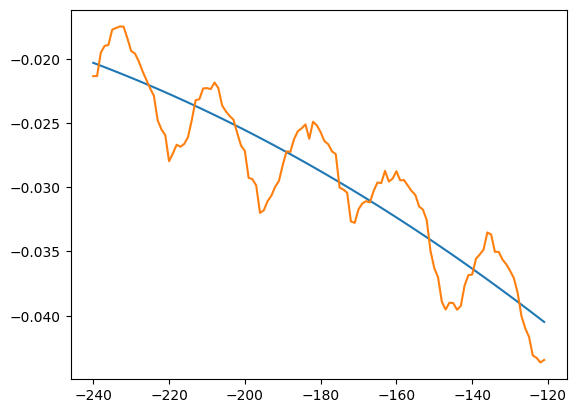

In [288]:
p = np.polyfit(t_train_tail_train, input_tail_train, deg=2)
poly_input_train = np.polyval(p, t_train_tail_train)
plt.plot(t_train_tail_train, poly_input_train)
plt.plot(t_train_tail_train, input_tail_train)

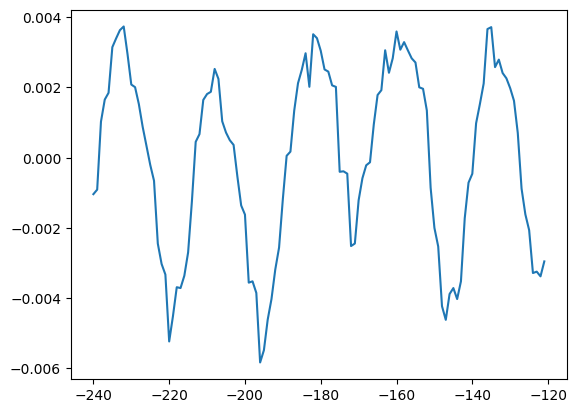

In [289]:
input_tail_detrend_train = input_tail_train - poly_input_train
plt.plot(t_train_tail_train, input_tail_detrend_train)

# Fit DMD

Don't forget to pick your input, e.g. `input_thin`, `input_tail` or `input_tail_detrended`.

In [290]:
V_i, t_i, shape_i = reshape_data2dmd(input_tail_detrend_train, 
                                     t_train_tail_train, time_delay = 40, 
                                     mask = None, isKeepFirstTimes = True)
V_i.shape, t_i.shape

((40, 81), (81,))

(4,) (40, 4) (4,)
[ 0.+0.25612016j -0.-0.25612016j  0.+0.08510217j -0.-0.08510217j]


/Users/pyatsyshin/miniconda3/envs/dmd_weather/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


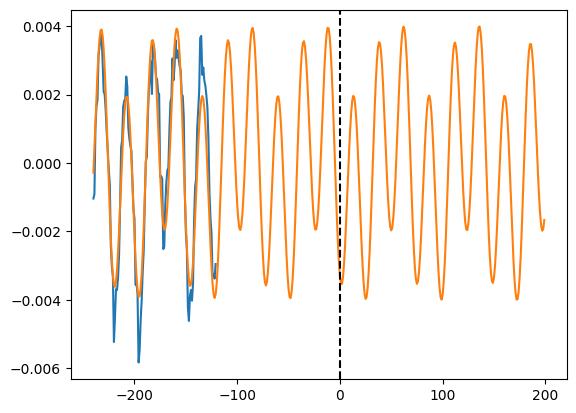

In [292]:
rank = 4

T_fin = 200
# train dmd
L_i, Psi_i_, bn_i = train_dmd(V_i, t_i, svd_rank = rank, 
                             eig_constraints=
                            #  limit_real
                           #   None
                             {
                                "imag", # choose Re(lambda)<0
                                "conjugate_pairs", # force complex conjugate pairs
                                } 
)


# reshape Psi to non-time-lagged spacial domain
Psi_i = Psi_i_[0]

print(L_i.shape, Psi_i_.shape, bn_i.shape)

# Psi_i = reshape_Psi2data(Psi_i_, shape_i, mask = None) # reshape to non-time-delayed shape
# Psi_i.shape
print(L_i)



t_pred = np.arange(t_train_tail_train[-1], T_fin)
t_all = np.concatenate((t_train_tail_train, t_pred))

V_i_pred = eval_dmd(L_i, Psi_i, bn_i, t_all, isPositive=False)


plt.plot(t_train_tail_train, input_tail_detrend_train);
plt.plot(t_all, V_i_pred);
plt.axvline(0, color = 'k', linestyle = '--')


## Add back trend

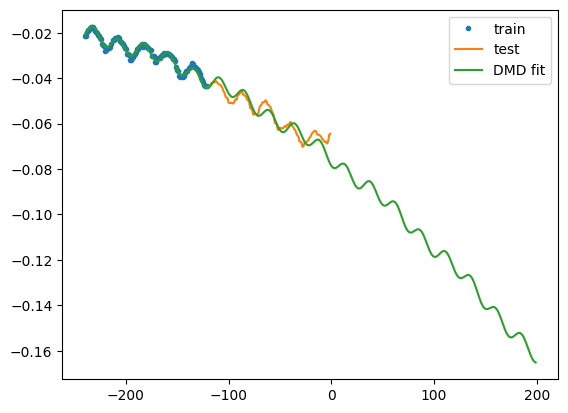

In [302]:
plt.plot(t_train_tail_train, input_tail_train, '.', label = 'train');
plt.plot(t_train_tail_test, input_tail_test, label = 'test');
plt.plot(t_all, V_i_pred+np.polyval(p, t_all), label = 'DMD fit')
plt.legend();
